In [2]:
# ==========================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES & CONFIGURATION
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
# ==========================================================
# 2. CHARGEMENT DU DATASET NETTOYÉ
# ==========================================================
df = pd.read_csv("online_retail_clean.csv", sep=",")
print(f"Taille du dataset (lignes, colonnes) : {df.shape}")

df_ventes = df[df['Quantity'] > 0].copy()
df_annulations = df[df['Quantity'] < 0].copy()

ca_total = df_ventes['Chiffre_Affaires'].sum()
ca_total_perte = df_annulations['Chiffre_Affaires'].sum()

print(f"Chiffre d'affaires total (Ventes) : {ca_total:,.2f} £")
print(f"Pertes totales (Annulations)      : {ca_total_perte:,.2f} £")

Taille du dataset (lignes, colonnes) : (1020771, 10)
Chiffre d'affaires total (Ventes) : 19,582,277.83 £
Pertes totales (Annulations)      : -711,483.32 £


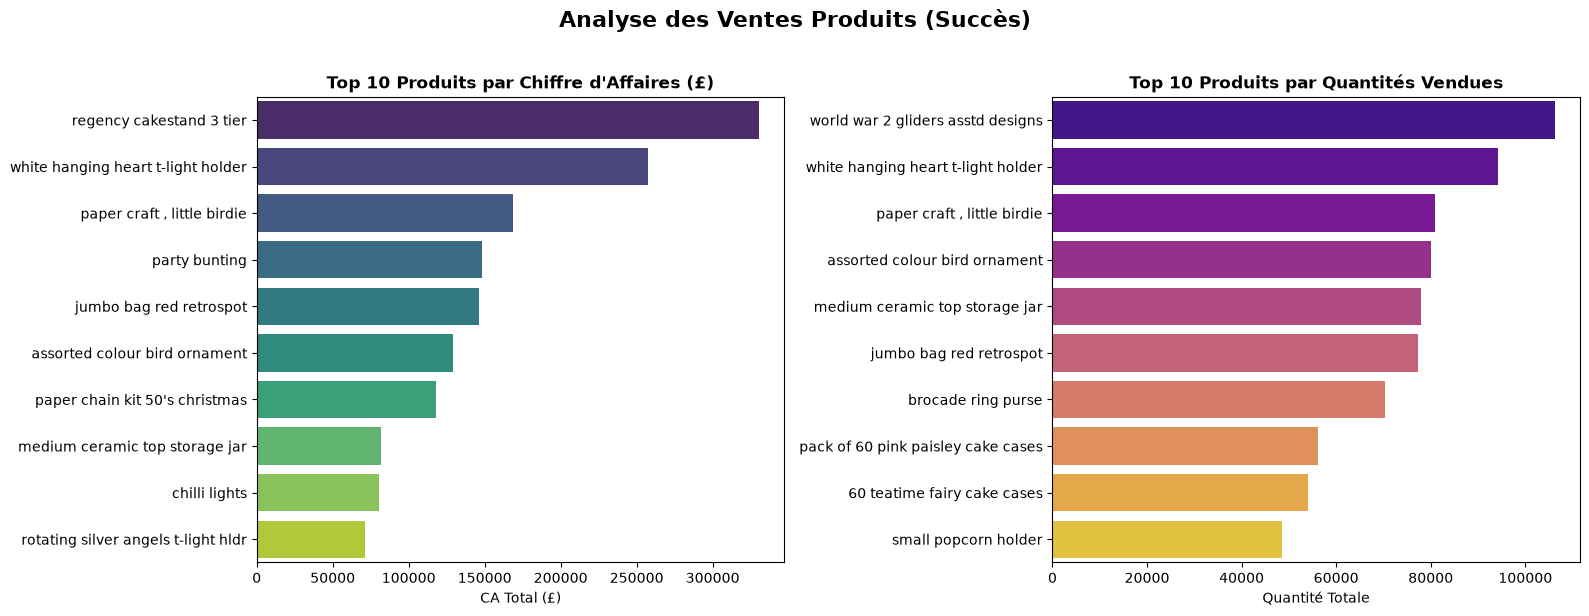

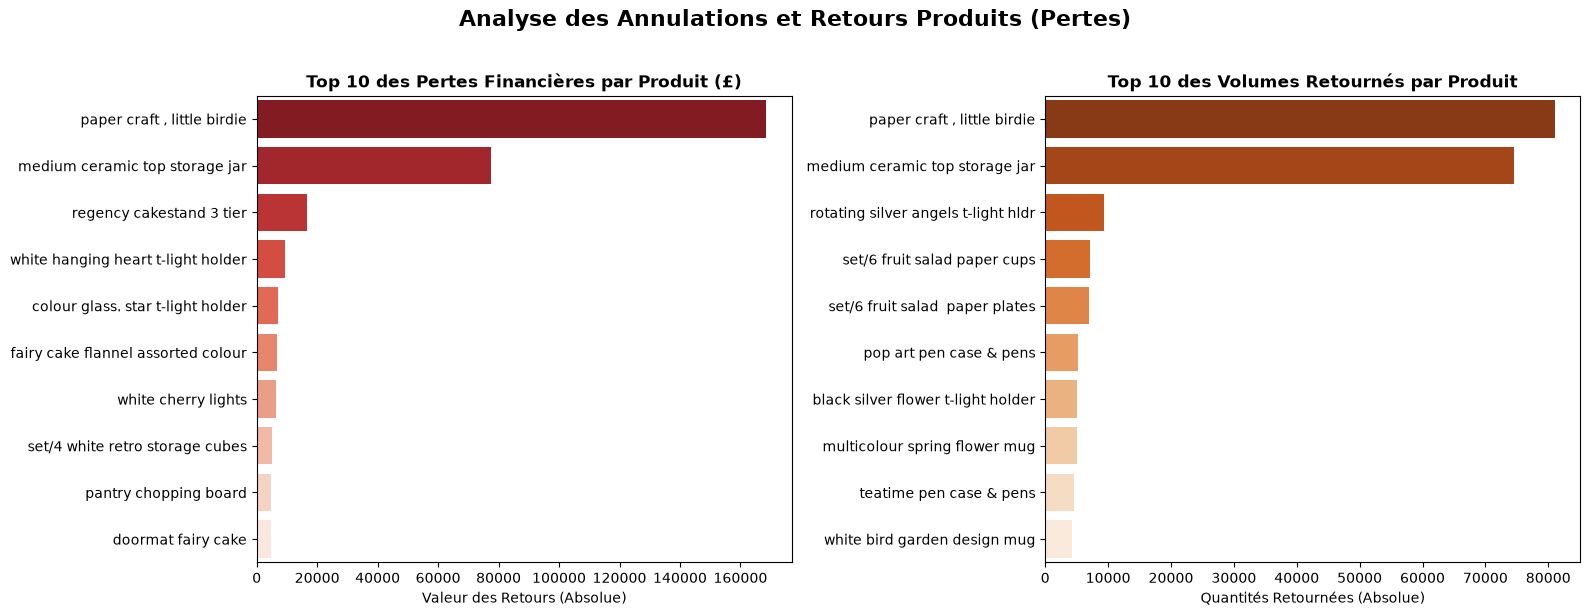

In [11]:
# ==========================================================
# 3. ANALYSE DES PRODUITS & VISUELS 
# ==========================================================

# 1. Calculs des Top 10
top10_produit_ca = df_ventes.groupby(["StockCode","Description"], as_index=False)["Chiffre_Affaires"].sum().reset_index()
top10_produit_ca =top10_produit_ca.sort_values(by="Chiffre_Affaires", ascending=False).head(10)

top10_produit_qty = df_ventes.groupby(["StockCode","Description"], as_index=False)["Quantity"].sum().reset_index()
top10_produit_qty = top10_produit_qty.sort_values(by="Quantity", ascending=False).head(10)

top10_produit_annul_ca = df_annulations.groupby(["StockCode","Description"], as_index=False)["Chiffre_Affaires"].sum().reset_index()
top10_produit_annul_ca =top10_produit_annul_ca .sort_values(by="Chiffre_Affaires", ascending=True).head(10)

top10_produit_annul_qty = df_annulations.groupby(["StockCode","Description"], as_index=False)["Quantity"].sum().reset_index()
top10_produit_annul_qty = top10_produit_annul_qty.sort_values(by="Quantity", ascending=True).head(10)


# --- GRAPHIQUE 1 : TOP 10 PRODUITS (Performances) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top10_produit_ca, x="Chiffre_Affaires", y="Description", hue="Description", ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Top 10 Produits par Chiffre d'Affaires (£)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("CA Total (£)")
axes[0].set_ylabel("")
sns.barplot(data=top10_produit_qty, x="Quantity", y="Description", hue="Description", ax=axes[1], palette="plasma", legend=False)
axes[1].set_title("Top 10 Produits par Quantités Vendues", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Quantité Totale")
axes[1].set_ylabel("")
plt.suptitle("Analyse des Ventes Produits (Succès)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- GRAPHIQUE 2 : TOP 10 RETOURS (Pertes) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top10_produit_annul_ca_visuel = top10_produit_annul_ca.copy()
top10_produit_annul_ca_visuel["Chiffre_Affaires_Perdu"] = top10_produit_annul_ca_visuel["Chiffre_Affaires"].abs()
sns.barplot(data=top10_produit_annul_ca_visuel, x="Chiffre_Affaires_Perdu", y="Description", hue="Description", ax=axes[0], palette="Reds_r", legend=False)
axes[0].set_title("Top 10 des Pertes Financières par Produit (£)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Valeur des Retours (Absolue)")
axes[0].set_ylabel("")
top10_produit_annul_qty_visuel = top10_produit_annul_qty.copy()
top10_produit_annul_qty_visuel["Quantite_Retournee"] = top10_produit_annul_qty_visuel["Quantity"].abs()
sns.barplot(data=top10_produit_annul_qty_visuel, x="Quantite_Retournee", y="Description", hue="Description", ax=axes[1], palette="Oranges_r", legend=False)
axes[1].set_title("Top 10 des Volumes Retournés par Produit", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Quantités Retournées (Absolue)")
axes[1].set_ylabel("")
plt.suptitle("Analyse des Annulations et Retours Produits (Pertes)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- IMPACT DU CLIENT FICTIF ---
CA généré par le client fictif 99999 : 2,571,006.13 £
Part du client fictif dans le CA total : 13.13 %



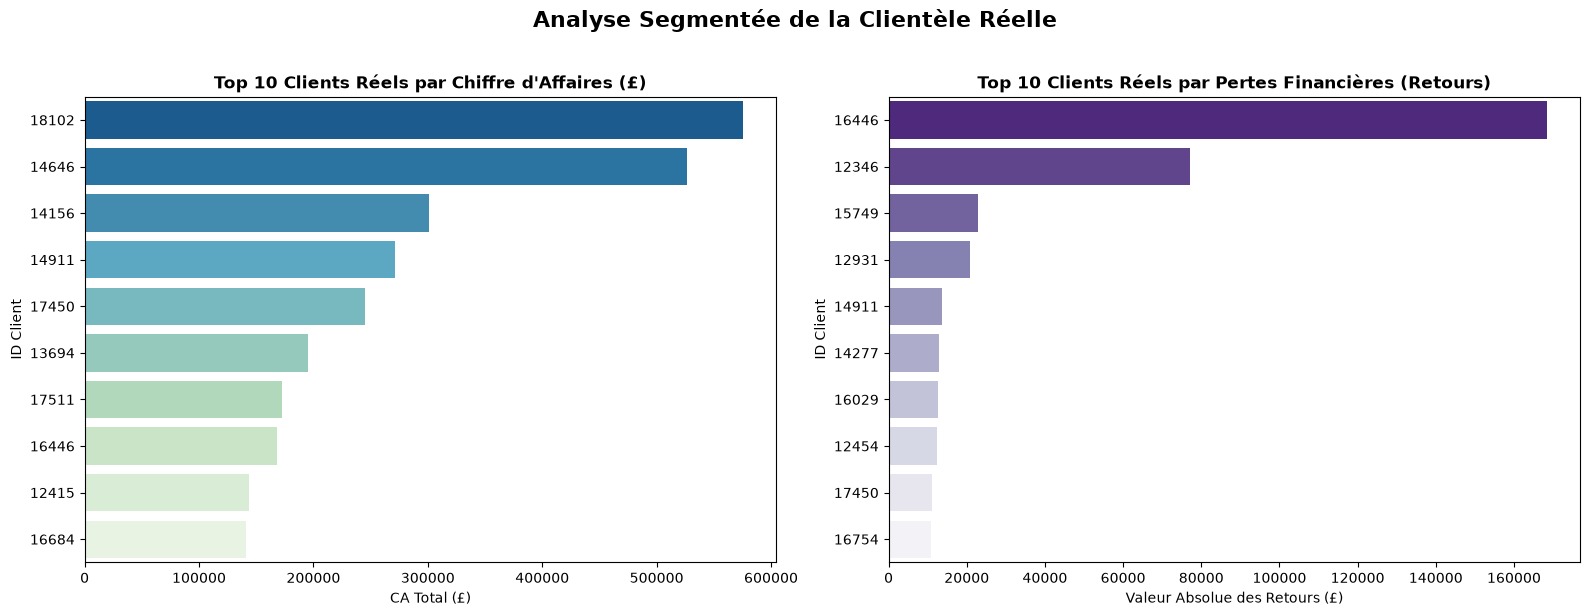

In [5]:
# ==========================================================
# 4. ANALYSE DES CLIENTS 
# ==========================================================

# 1. Analyse de l'impact du client fictif 99999
ca_client_fictif = df_ventes[df_ventes['Customer_ID'] == 99999]['Chiffre_Affaires'].sum()
taux_ca_client_fictif = (ca_client_fictif / ca_total) * 100
print("--- IMPACT DU CLIENT FICTIF ---")
print(f"CA généré par le client fictif 99999 : {ca_client_fictif:,.2f} £")
print(f"Part du client fictif dans le CA total : {taux_ca_client_fictif:.2f} %\n")

# 2. Top 10 des clients REELS (sans le 99999) générant le plus de CA
condition1 = df_ventes['Customer_ID'] != 99999
top10_client_ca_reel = df_ventes[condition1].groupby("Customer_ID", as_index=False)["Chiffre_Affaires"].sum().reset_index()
top10_client_ca_reel = top10_client_ca_reel.sort_values(by="Chiffre_Affaires", ascending=False).head(10)
top10_client_ca_reel["Customer_ID"] = top10_client_ca_reel["Customer_ID"].astype(str)

# 3. Top 10 des clients REELS faisant le plus de retours
condition2 = df_annulations['Customer_ID'] != 99999
top10_client_retour_reel = df_annulations[condition2].groupby("Customer_ID", as_index=False)["Chiffre_Affaires"].sum().reset_index()
top10_client_retour_reel = top10_client_retour_reel.sort_values(by="Chiffre_Affaires", ascending=True).head(10)

top10_client_retour_reel['Chiffre_Affaires_Perdu'] = top10_client_retour_reel['Chiffre_Affaires'].abs()
top10_client_retour_reel["Customer_ID"] = top10_client_retour_reel["Customer_ID"].astype(str)

# --- VISUALISATION DES CLIENTS RÉELS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique de gauche : Meilleurs clients (Correction hue et legend ajoutés)
sns.barplot(data=top10_client_ca_reel, x="Chiffre_Affaires", y="Customer_ID", hue="Customer_ID", ax=axes[0], palette="GnBu_r", legend=False)
axes[0].set_title("Top 10 Clients Réels par Chiffre d'Affaires (£)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("CA Total (£)")
axes[0].set_ylabel("ID Client")

# Graphique de droite : Clients avec le plus de retours (Correction de la variable y et ajout de hue)
sns.barplot(data=top10_client_retour_reel, x="Chiffre_Affaires_Perdu", y="Customer_ID", hue="Customer_ID", ax=axes[1], palette="Purples_r", legend=False)
axes[1].set_title("Top 10 Clients Réels par Pertes Financières (Retours)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Valeur Absolue des Retours (£)")
axes[1].set_ylabel("ID Client")

plt.suptitle("Analyse Segmentée de la Clientèle Réelle", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- MEILLEURS MOIS PAR ANNÉE ---
En 2010, le meilleur mois est : Novembre 
En 2011, le meilleur mois est : Novembre 


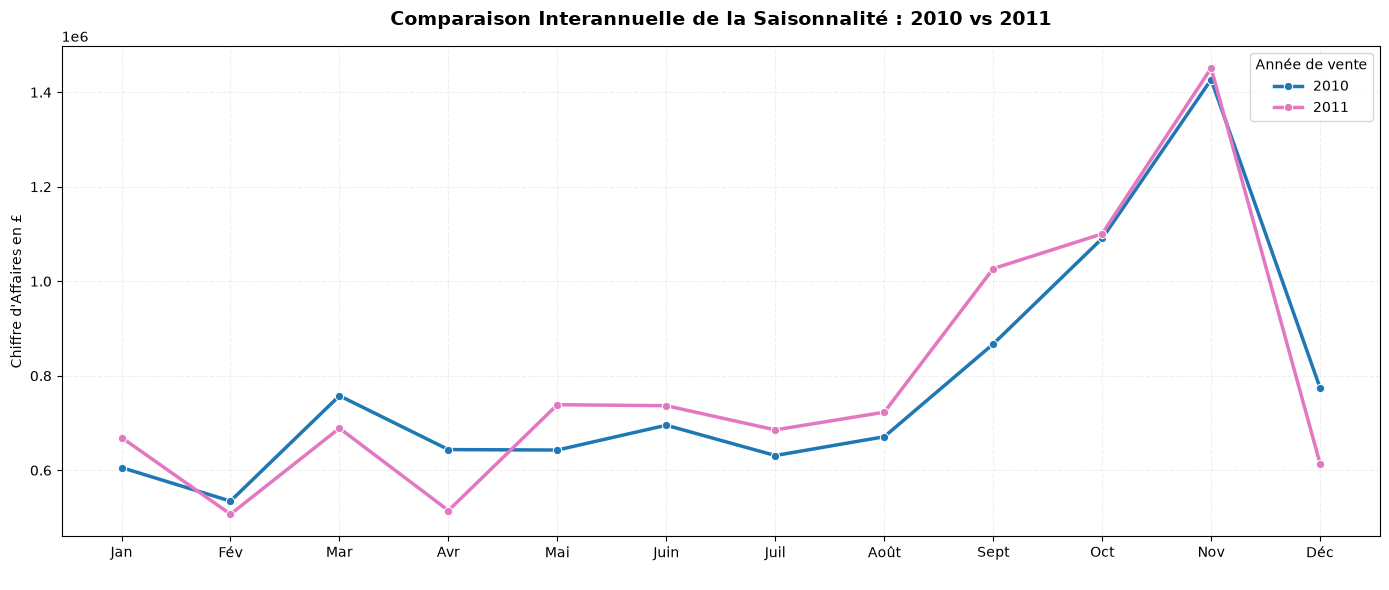

In [6]:
# ==========================================================
# 5. ANALYSE TEMPORELLE (SAISONNALITÉ)
# ==========================================================

df_ventes["InvoiceDate"] = pd.to_datetime(df_ventes["InvoiceDate"], format="mixed", errors="coerce", dayfirst=True)
df_ventes["Annee"] = df_ventes["InvoiceDate"].dt.year
df_ventes["Mois_Num"] = df_ventes["InvoiceDate"].dt.month
ca_saisonnalite = df_ventes.groupby(['Annee', 'Mois_Num'], as_index=False)["Chiffre_Affaires"].sum()
ca_saisonnalite = ca_saisonnalite[ca_saisonnalite['Annee'].isin([2010, 2011])]

noms_mois = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
print("--- MEILLEURS MOIS PAR ANNÉE ---")
for annee in [2010, 2011]:
    data_annee = ca_saisonnalite[ca_saisonnalite['Annee'] == annee]
    ligne_max = data_annee.loc[data_annee['Chiffre_Affaires'].idxmax()]
    num_mois = int(ligne_max['Mois_Num'])
    nom_mois = noms_mois[num_mois - 1] 
    ca_max = ligne_max['Chiffre_Affaires']
    print(f"En {annee}, le meilleur mois est : {nom_mois} ")

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=ca_saisonnalite, 
    x='Mois_Num', 
    y='Chiffre_Affaires', 
    hue='Annee',                
    marker='o', 
    linewidth=2.5,
    palette=['#1f77b4', '#e377c2'] # Bleu  2010, Rose pour 2011
)
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sept', 'Oct', 'Nov', 'Déc']
plt.xticks(ticks=range(1, 13), labels=noms_mois)
plt.title("Comparaison Interannuelle de la Saisonnalité : 2010 vs 2011", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Chiffre d'Affaires en £")
plt.xlabel(" ")
plt.legend(title="Année de vente", frameon=True)
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

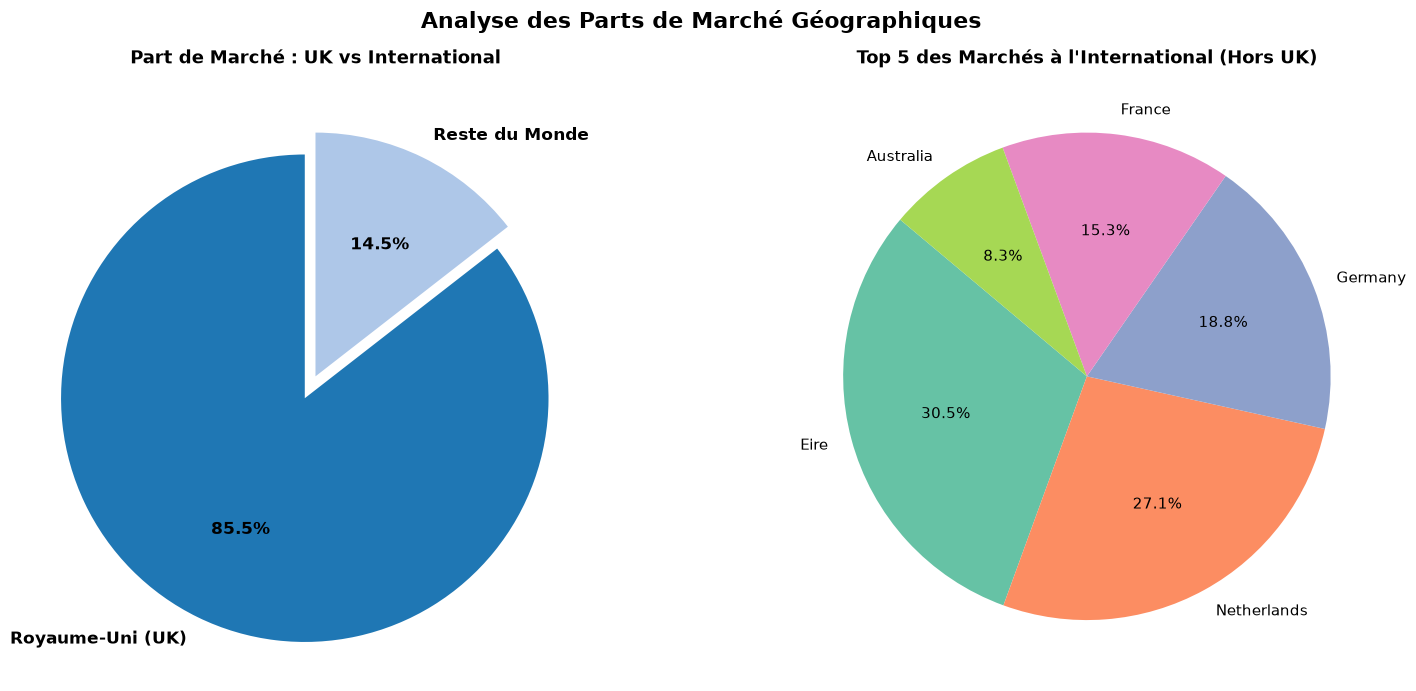

In [7]:
# ==========================================================
# 6. ANALYSE DES PARTS DE MARCHÉ GÉOGRAPHIQUES 
# ==========================================================

ca_par_pays = df_ventes.groupby("Country")["Chiffre_Affaires"].sum().sort_values(ascending=False)
ca_uk = ca_par_pays.get("United Kingdom", 0)
ca_reste = ca_par_pays.drop("United Kingdom", errors="ignore").sum()
df_uk_vs_reste = pd.DataFrame({"Zone": ["Royaume-Uni (UK)", "Reste du Monde"],"CA": [ca_uk, ca_reste]})
ca_international = ca_par_pays.drop("United Kingdom", errors="ignore").head(5).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : Dépendance UK
axes[0].pie(
    df_uk_vs_reste["CA"], 
    labels=df_uk_vs_reste["Zone"], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=["#1f77b4", "#aec7e8"],
    explode=(0.1, 0), # Détache un peu la part UK
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title("Part de Marché : UK vs International", fontsize=13, fontweight='bold')

# Graphique 2 : Zoom sur le Top 5 International
axes[1].pie(
    ca_international["Chiffre_Affaires"], 
    labels=ca_international["Country"], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Set2", len(ca_international)),
    textprops={'fontsize': 11}
)
axes[1].set_title("Top 5 des Marchés à l'International (Hors UK)", fontsize=13, fontweight='bold')
plt.suptitle("Analyse des Parts de Marché Géographiques", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================================
# 7. BILAN GLOBAL & INDICATEURS CLÉS (KPIs)
# ==========================================================
taille_dateset = df.shape[0]
total_commandes = df_ventes['Invoice'].nunique()
total_annulations = df_annulations['Invoice'].nunique()
taux_attrition_commandes = (total_annulations / total_commandes) * 100
taux_perte_financiere = (abs(ca_total_perte) / ca_total) * 100
panier_moyen = ca_total / total_commandes
grouped_pays = df_ventes.groupby("Country")
top5_pays_ca = df_ventes.groupby("Country")["Chiffre_Affaires"].sum().reset_index()
top5_pays_ca = top5_pays_ca.sort_values(by="Chiffre_Affaires", ascending=False).head(5)


print("="*60)
print("              TABLEAU DE BORD DE SYNTHÈSE RETAIL            ")
print("="*60)
print(f"Performance Commerciale :")
print(f"Chiffre d'Affaires Brut (Ventes)  : {ca_total:,.2f} £")
print(f"Volume total de commandes passées : {total_commandes:,}")
print(f"Montant du Panier Moyen           : {panier_moyen:.2f} £")
for i,pays in enumerate(top5_pays_ca['Country'],1):
    print(f"Top 5 marché géographique numéro {i} : {pays}")

print(" ")
print(f"Gestion des Risques & Retours :")
print(f"Manque à gagner (Annulations)     : {abs(ca_total_perte):,.2f} £")
print(f"Taux de perte financière          : {taux_perte_financiere:.2f} % du CA")
print(f"Taux d'annulation des commandes   : {taux_attrition_commandes:.2f} %")
print(f"")
print(f"Qualité de la Donnée :")
print(f"Total lignes de Transaction : {df.shape[0]}")
print(f"Poids du client fictif (99999)    : {taux_ca_client_fictif:.2f} % du CA")
print("="*60)
print(taille_dateset)

              TABLEAU DE BORD DE SYNTHÈSE RETAIL            
Performance Commerciale :
Chiffre d'Affaires Brut (Ventes)  : 19,582,277.83 £
Volume total de commandes passées : 39,745
Montant du Panier Moyen           : 492.70 £
Top 5 marché géographique numéro 1 : United Kingdom
Top 5 marché géographique numéro 2 : Eire
Top 5 marché géographique numéro 3 : Netherlands
Top 5 marché géographique numéro 4 : Germany
Top 5 marché géographique numéro 5 : France
 
Gestion des Risques & Retours :
Manque à gagner (Annulations)     : 711,483.32 £
Taux de perte financière          : 3.63 % du CA
Taux d'annulation des commandes   : 18.60 %

Qualité de la Donnée :
Total lignes de Transaction : 1020771
Poids du client fictif (99999)    : 13.13 % du CA
1020771
